- https://gemini.google.com/app/487a9000dd464a23

- Score Function (得分函数估计器) 和 Path Derivative (路径导数估计器)
    - 如果计算过程中包含“随机采样”这一步（例如 VAE 中的潜变量采样，或强化学习中的动作采样），标准的反向传播会被打断（因为采样不可导）。这两个方法就是为了“修补”这个断裂的梯度。
- Score Function (REINFORCE) —— “黑盒尝试”
    - 机制：你蒙着眼开了一枪，助手告诉你“得了 10 分”。你虽然不知道风速和弹道（不知道环境的具体模型），但你心里想：“既然这次得分高，那我就记住刚才的站位和姿势，下次还这么站。”
    - 核心逻辑：如果结果好，就增加产生该结果的概率。
    - 特点：不关心环境内部结构，只要有奖励反馈就行。但因为没利用环境信息，尝试的方差（波动）极大。
    - 适用范围：NLP 生成（离散 Token）或复杂的 RL 环境（不可导 Reward），最好Baseline（如减去平均 Reward）来降低方差。
- Path Derivative (Reparameterization) —— “白盒调整”
    - 机制：你知道枪的构造和风速公式。你把“开枪”分解为两步：确定瞄准方向（参数）+ 扣动扳机时的手抖（随机噪声）。
    - 核心逻辑：你可以计算出：“如果不考虑手抖，我把枪口往左移 1 厘米，子弹就会往左移 1 厘米，分数会提高 5 分。”
    - 特点：利用了环境的可导性（需要知道 Loss 函数的导数）。因为直接利用了因果链条，方差极小，收敛极快。
    - 适用范围：VAE 或连续控制

> 最小化期望损失 $J(\theta)$，需要求梯度 $\nabla_\theta J(\theta)$。

$$
J(\theta) = \mathbb{E}_{x \sim p_\theta(x)} [f(x)]
$$

- Score Function Estimator (SF): 利用对数导数技巧（Log-Derivative Trick）：
  $$\nabla_\theta J(\theta) = \mathbb{E}_{x \sim p_\theta(x)} [ f(x) \cdot \nabla_\theta \log p_\theta(x) ]$$
    - 简单证明
        - $\nabla_\theta J(\theta) = \int \nabla_\theta \left( p_\theta(x) f(x) \right) \, dx= \int \left( \nabla_\theta p_\theta(x) \right) f(x) \, dx= \int p_\theta(x) \nabla_\theta \log p_\theta(x) f(x) \, dx= \mathbb{E}_{x \sim p_\theta(x)} [ \nabla_\theta \log p_\theta(x) \cdot f(x) ]$
    - 含义：$f(x)$ 是权重。如果 $f(x)$ 很小（Loss低/Reward高），就沿着 $\nabla \log p(x)$ 方向走（增加概率）。
    - 适用性：$f(x)$ 可以不可导，甚至可以是离散的。
    - 缺点：梯度方差随 $f(x)$ 的量级波动，通常需要 Subtract Baseline 来减小方差。
- Path Derivative Estimator (PD)
    - 利用重参数化技巧（Reparameterization Trick）。将随机变量 $x$ 重写为确定性函数 $g$ 和外部噪声 $\epsilon$ 的组合：$x = g(\theta, \epsilon), \epsilon \sim p(\epsilon)$
    $$\nabla_\theta J(\theta) = \mathbb{E}_{\epsilon \sim p(\epsilon)} [ \nabla_x f(g(\theta, \epsilon)) \cdot \nabla_\theta g(\theta, \epsilon) ]$$
    - 简单证明
        - 重参数化 (Reparameterization Trick)：我们将随机变量 $x$ 表示为一个确定性函数 $g$ 和一个独立于 $\theta$ 的噪声 $\epsilon$ 的组合：$x = g(\theta, \epsilon), \quad \epsilon \sim p(\epsilon)$
            - 正态分布 $x \sim \mathcal{N}(\mu, \sigma^2)$ 可以写成 $x = \mu + \sigma \cdot \epsilon$，其中 $\epsilon \sim \mathcal{N}(0, 1)$。
        - 根据无意识统计学家定律 (Law of the Unconscious Statistician)，我们可以把对 $x$ 的期望转化为对噪声 $\epsilon$ 的期望。$J(\theta) = \mathbb{E}_{x \sim p_\theta(x)} [f(x)] = \mathbb{E}_{\epsilon \sim p(\epsilon)} [f(g(\theta, \epsilon))]= \int p(\epsilon) f(g(\theta, \epsilon)) \, d\epsilon$
        - 交换积分与微分：现在我们要对 $\theta$ 求导。注意，现在的概率密度 $p(\epsilon)$ 不包含 $\theta$（这是关键！）。$\theta$ 只存在于 $f(g(\dots))$ 内部。
            - $\nabla_\theta J(\theta) = \nabla_\theta \int p(\epsilon) f(g(\theta, \epsilon)) \, d\epsilon= \int p(\epsilon) \nabla_\theta f(g(\theta, \epsilon)) \, d\epsilon$
        - 链式法则 (Chain Rule)：对内部复合函数求导。我们需要 $f$ 对 $x$ 可导，且 $g$ 对 $\theta$ 可导。
            - $\nabla_\theta f(g(\theta, \epsilon)) = \nabla_x f(x) \bigg|_{x=g(\theta, \epsilon)} \cdot \nabla_\theta g(\theta, \epsilon)$
        - 得到：$\mathbb{E}_{\epsilon \sim p(\epsilon)} [ \nabla_x f(g(\theta, \epsilon)) \cdot \nabla_\theta g(\theta, \epsilon) ]$
    - 含义：直接通过链式法则，把梯度从 Loss $f$ 传回 $x$，再穿过变换 $g$ 传回 $\theta$。
    - 适用性：要求 $f(x)$ 和 $g(\theta, \epsilon)$ 必须处处可导。
    - 优点：利用了 $f(x)$ 的局部几何信息（斜率），估计非常精准。

### 计算图-梯度流

- Score Function: $\theta \to p_\theta \to \text{Sample } x \to f(x)$
    - 梯度流到 $x$ 就断了（因为采样操作不可导）。
    - SF 重建了一个“旁路”，直接问 $p_\theta$：“怎么样调整参数能让这个 $x$ 出现的概率变大？”然后用 $f(x)$ 加权。
- Path Derivative: $\epsilon \to [\text{Transform } g(\theta, \epsilon)] \to x \to f(x)$
    - 随机性被剥离到了 $\epsilon$。
    - $\theta$ 是变换函数 $g$ 的参数。
    - 梯度流是一条通畅的大路： $\theta \leftarrow g \leftarrow x \leftarrow f$。

### misc

$$
s(\theta) = \nabla_\theta \log p(x; \theta)
$$
- Score Function（得分函数）的期望为 0。

$$
\begin{aligned}
\mathbb{E}_{x \sim p(x;\theta)} [s(\theta)] &= \mathbb{E}_{x \sim p(x;\theta)} [\nabla_\theta \log p(x; \theta)] \\
&= \int p(x; \theta) \nabla_\theta \log p(x; \theta) \, dx \\
&= \int p(x; \theta) \frac{\nabla_\theta p(x; \theta)}{p(x; \theta)} \, dx \quad (\text{利用对数导数技巧: } \nabla \log f = \frac{\nabla f}{f}) \\
&= \int \nabla_\theta p(x; \theta) \, dx \\
&= \nabla_\theta \int p(x; \theta) \, dx \quad (\text{交换积分与微分运算}) \\
&= \nabla_\theta (1) \quad (\text{概率密度函数的积分为 1}) \\
&= 0
\end{aligned}
$$

### examples

寻找高斯分布的最优均值 $\mu$，使其采样出的 $x$ 最小化 $L(x) = (x - \text{target})^2$。

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子以复现
torch.manual_seed(42)
np.random.seed(42)

# === 配置 ===
TARGET = 3.0          # 目标值
INIT_MU = 0.0         # 初始均值
SIGMA = 1.0           # 固定标准差
LR = 0.1              # 学习率
ITERATIONS = 500
BATCH_SIZE = 64       # 每次采样的数量

def run_optimization(method='path_derivative'):
    # 初始化参数 mu (需要梯度)
    mu = torch.tensor([INIT_MU], requires_grad=True)
    optimizer = torch.optim.Adam([mu], lr=LR)
    
    loss_history = []
    grad_variance_history = []
    mu_history = []

    for _ in range(ITERATIONS):
        optimizer.zero_grad()
        
        # 1. 采样与计算 Loss
        if method == 'path_derivative':
            # Reparameterization Trick: x = mu + sigma * epsilon
            # PyTorch 的 rsample() 自动包含了这一步，并保持了梯度流
            dist = torch.distributions.Normal(mu, SIGMA)
            x = dist.rsample((BATCH_SIZE,)) 
            loss = (x - TARGET) ** 2  # f(x)
            
            # Loss 直接对 mu 可导
            loss_mean = loss.mean()
            loss_mean.backward()
            
        elif method == 'score_function':
            # Score Function (REINFORCE)
            dist = torch.distributions.Normal(mu, SIGMA)
            x = dist.sample((BATCH_SIZE,)) # sample() 切断了梯度流，x 对 mu 不可导
            
            # 这里的 loss_val 仅仅作为系数 (reward/cost)
            loss_val = (x - TARGET) ** 2
            
            # SF 梯度核心公式: E[ f(x) * grad(log_prob) ]
            # 在 PyTorch 中通常构建一个代理损失(Surrogate Loss)来实现:
            # L_surrogate = log_prob * loss_val.detach()
            log_prob = dist.log_prob(x)
            # 注意：必须 detach loss_val，否则会变成错误的混合导数
            loss_surrogate = log_prob * loss_val.detach()
            
            loss_surrogate_mean = loss_surrogate.mean()
            loss_surrogate_mean.backward()
            
            # 记录实际用于显示的 Loss (不带梯度)
            loss_mean = loss_val.mean()

        # 记录数据
        loss_history.append(loss_mean.item())
        mu_history.append(mu.item())
        
        # === 关键：记录梯度的方差 ===
        # 我们手动计算这一个 Batch 中每个样本产生的梯度的方差
        if method == 'path_derivative':
            # PD 单样本梯度: 2(x - target) * 1
            grads = 2 * (x - TARGET)
        else: 
            # SF 单样本梯度: (x - target)^2 * (x - mu)/sigma^2
            # 假设 sigma=1
            grads = (x - TARGET)**2 * (x - mu.detach())
            
        grad_variance_history.append(torch.var(grads).item())

        optimizer.step()
        
    return loss_history, grad_variance_history, mu_history

# === 运行实验 ===
print("Running Path Derivative (Reparam)...")
pd_loss, pd_var, pd_mu = run_optimization('path_derivative')

print("Running Score Function (REINFORCE)...")
sf_loss, sf_var, sf_mu = run_optimization('score_function')

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Running Path Derivative (Reparam)...
Running Score Function (REINFORCE)...


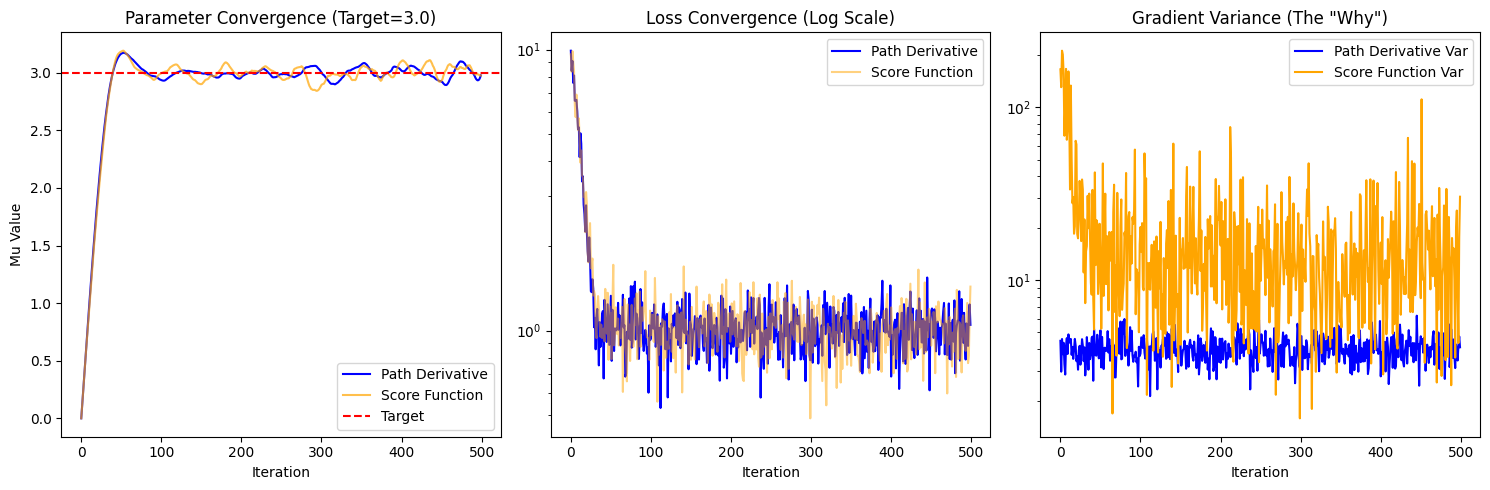

In [2]:
# === 可视化 ===
plt.figure(figsize=(15, 5))

# 1. 参数收敛曲线
plt.subplot(1, 3, 1)
plt.plot(pd_mu, label='Path Derivative', color='blue')
plt.plot(sf_mu, label='Score Function', color='orange', alpha=0.7)
plt.axhline(y=TARGET, color='r', linestyle='--', label='Target')
plt.title(f'Parameter Convergence (Target={TARGET})')
plt.xlabel('Iteration')
plt.ylabel('Mu Value')
plt.legend()

# 2. Loss 曲线 (对数坐标)
plt.subplot(1, 3, 2)
plt.plot(pd_loss, label='Path Derivative', color='blue')
plt.plot(sf_loss, label='Score Function', color='orange', alpha=0.5)
plt.yscale('log')
plt.title('Loss Convergence (Log Scale)')
plt.xlabel('Iteration')
plt.legend()

# 3. 梯度方差 (关键!)
plt.subplot(1, 3, 3)
plt.plot(pd_var, label='Path Derivative Var', color='blue')
plt.plot(sf_var, label='Score Function Var', color='orange')
plt.yscale('log')
plt.title('Gradient Variance (The "Why")')
plt.xlabel('Iteration')
plt.legend()

plt.tight_layout()